# Cambodia Tourism Chatbot — Training Notebook


###  Project Overview

> In this project, you will build a Natural Language Processing (NLP) model using a **Simple Recurrent Neural Network (RNN)**. The goal is to create a chatbot that can answer common questions about tourism in Cambodia, covering destinations, food, and travel logistics
---

## 1. Import Libraries

We begin by importing the necessary libraries. `pandas` and `numpy` handle data manipulation, `tensorflow.keras` provides the deep learning components (Embedding, SimpleRNN, Dense layers), `scikit-learn` is used for splitting the dataset, and `pickle` is used to persist the tokenizer and configuration. Random seeds are set to make the results reproducible.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# print("Libraries loaded successfully")
# print(f"TensorFlow version: {tf.__version__}")

## 2. Load the Dataset

The dataset `cambodia_tourism_dataset_large.csv` contains question–answer pairs about Cambodia tourism. Each row represents one training example: the `question` column holds the user's input, and the `answer` column holds the expected chatbot response. We load it into a pandas DataFrame and inspect the first few rows to confirm the structure.

In [2]:
df = pd.read_csv("cambodia_tourism_dataset_large.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Dataset shape: (2000, 2)
Columns: ['question', 'answer']


,question,answer
0,can you explain where is angkor wat specifically.,angkor wat is in siem reap cambodia
1,give me details on what is angkor wat for me.,it is a famous temple in cambodia
2,hey what to do in siem reap specifically.,you can visit temples and night market
3,do you know where is bayon temple immediately.,bayon temple is in the center of angkor thom
4,do you know what is ta prohm specifically.,it is the jungle temple with giant trees in si...
5,hi how much is angkor pass thank you.,a 1-day pass is 37 dollars and a 3-day pass is...
6,do you know where to watch sunset in siem reap...,phnom bakheng is the most popular spot for sunset
7,what is pub street?,it is the nightlife hub of siem reap with bars...
8,is tonle sap near siem reap specifically.,yes it is the largest freshwater lake near sie...
9,can you tell me best time to visit temples,early morning at sunrise is the best time


## 3. Explore the Dataset

Before preprocessing, it is useful to understand the basic statistics of the dataset, particularly the length of questions and answers in words. These statistics will guide our choice of `max_len` (the fixed sequence length used during padding). We also check for missing values that could cause errors during training.

In [3]:
print(f"Total samples: {len(df)}")
print(f"\nMissing values:\n{df.isnull().sum()}")

df['question_length'] = df['question'].astype(str).apply(lambda x: len(x.split()))
df['answer_length'] = df['answer'].astype(str).apply(lambda x: len(x.split()))

print(f"\nQuestion length - max: {df['question_length'].max()}, average: {df['question_length'].mean():.1f}")
print(f"Answer length   - max: {df['answer_length'].max()}, average: {df['answer_length'].mean():.1f}")

Total samples: 2000

Missing values:
question    0
answer      0
dtype: int64

Question length - max: 14, average: 8.7
Answer length   - max: 13, average: 8.7


### Visualize Length Distributions

Histograms of question and answer lengths help us decide where to set the maximum sequence length. We want a value that captures most of the data without wasting memory on extreme outliers.

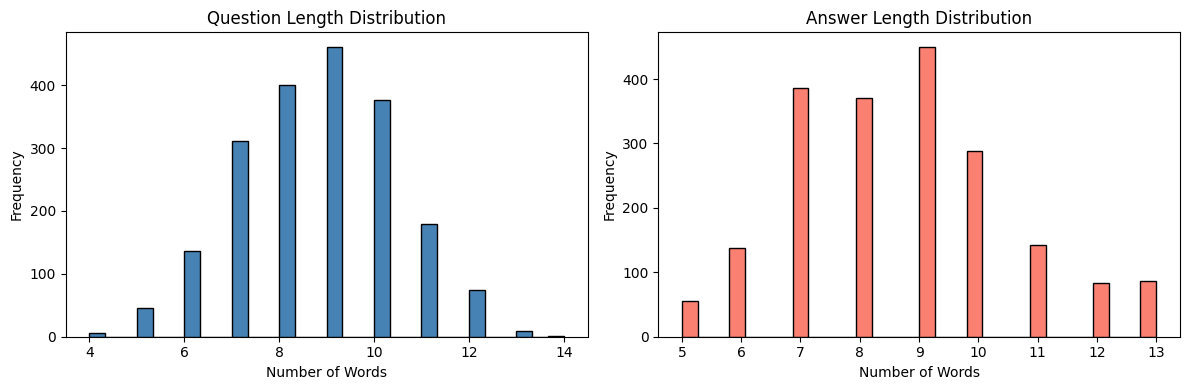

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['question_length'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Question Length Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['answer_length'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Answer Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 4. Prepare Inputs and Responses

We extract the `question` and `answer` columns into two parallel Python lists. These will serve as the input and target sequences for the model.

In [5]:
inputs = df["question"].astype(str).tolist()
responses = df["answer"].astype(str).tolist()

print(f"Number of input questions: {len(inputs)}")
print(f"Number of responses: {len(responses)}")
print(f"\nSample input:    {inputs[0]}")
print(f"Sample response: {responses[0]}")

Number of input questions: 2000
Number of responses: 2000

Sample input:    can you explain where is angkor wat specifically.
Sample response: angkor wat is in siem reap cambodia


## 5. Tokenization

Neural networks cannot process raw text directly, so we convert each word into an integer index using a Keras `Tokenizer`. The tokenizer is fit on both the questions and the answers so that the same vocabulary is shared between input and output. We also include an `<OOV>` token to handle unknown words seen at inference time. The vocabulary size will determine the size of the embedding layer and the output softmax layer.

In [6]:
tokenizer = Tokenizer(filters='', oov_token='<OOV>')
tokenizer.fit_on_texts(inputs + responses)
vocab_size = len(tokenizer.word_index) + 1

X_seq = tokenizer.texts_to_sequences(inputs)
y_seq = tokenizer.texts_to_sequences(responses)

print(f"Vocabulary size: {vocab_size}")
print(f"\nOriginal question: {inputs[0]}")
print(f"Tokenized:         {X_seq[0]}")
print(f"\nOriginal response: {responses[0]}")
print(f"Tokenized:         {y_seq[0]}")

Vocabulary size: 422

Original question: can you explain where is angkor wat specifically.
Tokenized:         [14, 6, 25, 11, 2, 20, 38, 39]

Original response: angkor wat is in siem reap cambodia
Tokenized:         [20, 38, 2, 4, 24, 22, 19]


## 6. Padding

Recurrent neural networks require all input sequences in a batch to have the same length. We pad shorter sequences with zeros and truncate longer ones to a chosen `max_len`. We use the 95th percentile of the combined question and answer lengths as `max_len`, which keeps most of the data intact while avoiding the memory overhead of accommodating extreme outliers.

In [7]:
all_lengths = [len(s) for s in X_seq] + [len(s) for s in y_seq]
max_len = int(np.percentile(all_lengths, 95))

print(f"Chosen max_len (95th percentile): {max_len}")

X = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')
y = pad_sequences(y_seq, maxlen=max_len, padding='post', truncating='post')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Chosen max_len (95th percentile): 12
X shape: (2000, 12)
y shape: (2000, 12)


## 7. Train/Test Split

We hold out 20% of the data as a validation set so that we can monitor how well the model generalizes to unseen examples during training. A fixed `random_state` makes the split reproducible.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (1600, 12)
Test set:     (400, 12)


## 8. Build the SimpleRNN Model

The architecture is a straightforward sequence-to-sequence model:

- **Embedding layer**: maps each integer token to a dense 64-dimensional vector. `mask_zero=True` tells downstream layers to ignore padded positions.
- **SimpleRNN layer**: a recurrent layer with 128 units. `return_sequences=True` makes it output one hidden state per time step, which is required for predicting a word at every position of the response.
- **Dense layer**: a fully connected layer with `vocab_size` units and softmax activation, producing a probability distribution over the vocabulary at each time step.

We compile the model with the Adam optimizer and `sparse_categorical_crossentropy` as the loss. Using the *sparse* version of categorical crossentropy means we can keep the targets as integer sequences rather than one-hot encoding them, which dramatically reduces memory usage when the vocabulary is large.

In [9]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len, mask_zero=True),
    SimpleRNN(128, return_sequences=True),
    Dense(vocab_size, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 12, 64)            27008     
                                                                 
 simple_rnn (SimpleRNN)      (None, 12, 128)           24704     
                                                                 
 dense (Dense)               (None, 12, 422)           54438     
                                                                 
Total params: 106150 (414.65 KB)
Trainable params: 106150 (414.65 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 9. Train the Model

We train the model for 250 epochs with a batch size of 32. The validation set is used to monitor generalization. Training a recurrent network on this scale typically takes several minutes depending on hardware.

In [14]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=500,
    batch_size=32,
    verbose=1
)

Epoch 1/500
50/50 [==============================] - 0s 6ms/step - loss: 1.1638 - accuracy: 0.6486 - val_loss: 1.5985 - val_accuracy: 0.5863
Epoch 2/500
50/50 [==============================] - 0s 5ms/step - loss: 1.1619 - accuracy: 0.6476 - val_loss: 1.5945 - val_accuracy: 0.5866
Epoch 3/500
50/50 [==============================] - 0s 5ms/step - loss: 1.1655 - accuracy: 0.6485 - val_loss: 1.6060 - val_accuracy: 0.5871
Epoch 4/500
50/50 [==============================] - 0s 5ms/step - loss: 1.1658 - accuracy: 0.6448 - val_loss: 1.6001 - val_accuracy: 0.5874
Epoch 5/500
50/50 [==============================] - 0s 5ms/step - loss: 1.1645 - accuracy: 0.6474 - val_loss: 1.5982 - val_accuracy: 0.5911
Epoch 6/500
50/50 [==============================] - 0s 5ms/step - loss: 1.1652 - accuracy: 0.6474 - val_loss: 1.6034 - val_accuracy: 0.5854
Epoch 7/500
50/50 [==============================] - 0s 5ms/step - loss: 1.1654 - accuracy: 0.6458 - val_loss: 1.5926 - val_accuracy: 0.5894
Epoch 8/500
5

## 10. Visualize Training Performance

We plot the training and validation loss and accuracy across epochs. This is helpful for diagnosing overfitting (validation loss rising while training loss continues to fall) or underfitting (both losses staying high), and it provides evidence of model behavior to discuss in the report.

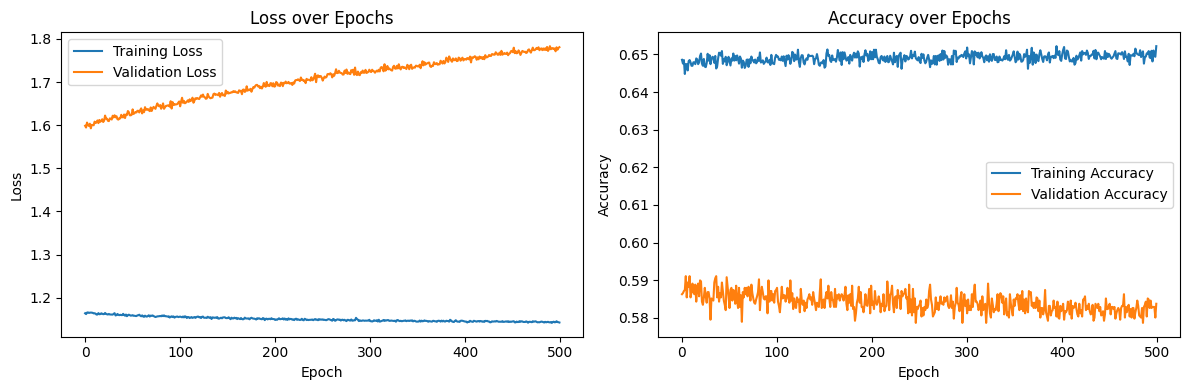

Final training accuracy:   0.6522
Final validation accuracy: 0.5837


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Final training accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

## 11. Save Model and Artifacts

We save three files so that the prediction notebook and the Streamlit app can load the trained chatbot without retraining:

- **`model.h5`** — the trained Keras model weights and architecture.
- **`tokenizer.pkl`** — the fitted tokenizer used to convert text into integer sequences.
- **`config.pkl`** — a small dictionary holding the `max_len` and `vocab_size` used during training, which the prediction code needs to reproduce the same preprocessing.

In [12]:
model.save("model.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("config.pkl", "wb") as f:
    pickle.dump({"max_len": max_len, "vocab_size": vocab_size}, f)

print("Saved model.h5, tokenizer.pkl, and config.pkl")

Saved model.h5, tokenizer.pkl, and config.pkl


c:\Users\setha.proeung\Desktop\Final Project\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 12. Quick Sanity Check

Before moving on to the prediction notebook, we run one example question through the trained model to verify that the saved artifacts work end-to-end.

In [13]:
index_to_word = {v: k for k, v in tokenizer.word_index.items()}

def quick_predict(text):
    seq = tokenizer.texts_to_sequences([text.lower()])
    seq = pad_sequences(seq, maxlen=max_len, padding='post')
    pred = model.predict(seq, verbose=0)
    pred_ids = np.argmax(pred, axis=-1)[0]
    words = [index_to_word.get(i, '') for i in pred_ids if i != 0]
    return " ".join(words)

test_question = "Where is Angkor Wat?"
print(f"Q: {test_question}")
print(f"A: {quick_predict(test_question)}")

Q: Where is Angkor Wat?
A: it is is and and and and and and and and and
